In [6]:
from pathlib import Path
from collections import Counter

# ── 여기만 본인 labels 폴더 경로로 수정 ──
BASE = Path(r"C:\Users\User\Desktop\MangoFruitBD A Bounding-Box Annotated Image Datase\MangoFruitBD\MangoFruitBD\labels")
SPLITS = ["train", "val", "test"]
# ────────────────────────────────────

total = Counter()

for split in SPLITS:
    folder = BASE / split
    if not folder.exists():
        print(f"[건너뜀] 폴더 없음: {folder}")
        continue

    split_counter = Counter()
    txt_files = list(folder.glob("*.txt"))

    for txt in txt_files:
        prefix = txt.stem.split("(")[0]   # 파일명에서 '_' 앞부분
        split_counter[prefix] += 1

    print(f"\n=== {split} (파일 {len(txt_files)}개) ===")
    for cls, cnt in sorted(split_counter.items()):
        print(f"  class {cls}: {cnt}")
    total.update(split_counter)

print("\n===== 전체 합계 =====")
for cls, cnt in sorted(total.items()):
    print(f"  class {cls}: {cnt}")
print(f"  총 라벨 개수: {sum(total.values())}")


=== train (파일 1048개) ===
  class Alternaria : 186
  class Anthracnose : 224
  class Background : 19
  class Healthy : 364
  class Mixed: 102
  class Scab : 153

=== val (파일 131개) ===
  class Alternaria : 26
  class Anthracnose : 32
  class Background : 2
  class Healthy : 36
  class Mixed: 17
  class Scab : 18

=== test (파일 131개) ===
  class Alternaria : 26
  class Anthracnose : 27
  class Background : 3
  class Healthy : 37
  class Mixed: 9
  class Scab : 29

===== 전체 합계 =====
  class Alternaria : 238
  class Anthracnose : 283
  class Background : 24
  class Healthy : 437
  class Mixed: 128
  class Scab : 200
  총 라벨 개수: 1310


In [ ]:
pip install matplotlib

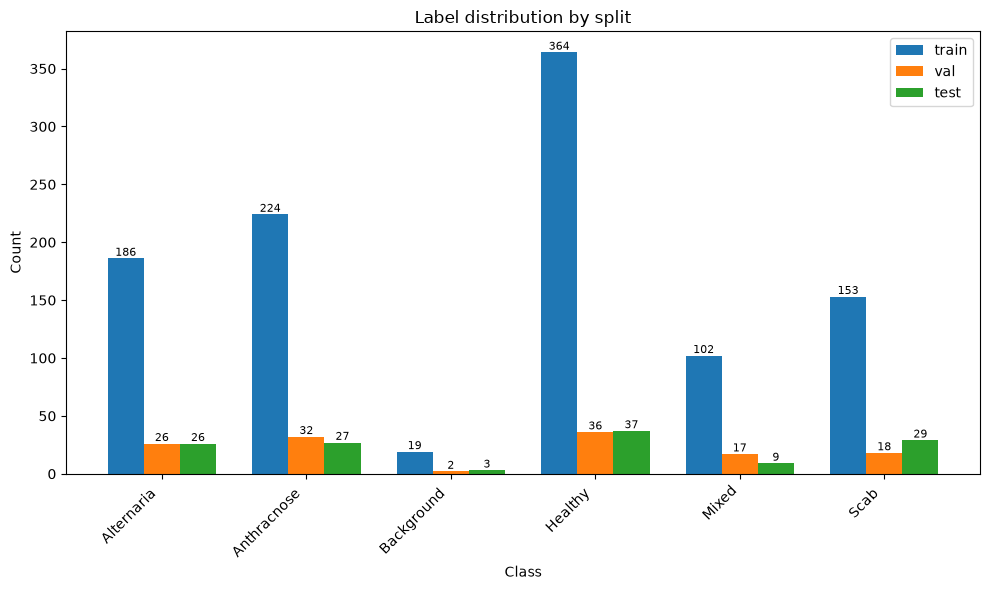

In [10]:
import matplotlib.pyplot as plt

# ── 본인 labels 폴더 경로로 수정 ──
BASE = Path(r"C:\Users\User\Desktop\MangoFruitBD A Bounding-Box Annotated Image Datase\MangoFruitBD\MangoFruitBD\labels")
SPLITS = ["train", "val", "test"]
# ─────────────────────────────────

counts_per_split = {}   # split별 클래스 카운트 저장
total = Counter()

for split in SPLITS:
    folder = BASE / split
    if not folder.exists():
        print(f"[건너뜀] 폴더 없음: {folder}")
        counts_per_split[split] = Counter()
        continue

    split_counter = Counter()
    txt_files = list(folder.glob("*.txt"))
    
    for txt in txt_files:
        prefix = txt.stem.split("(")[0]   # 파일명에서 '_' 앞부분
        split_counter[prefix] += 1

    counts_per_split[split] = split_counter
    total.update(split_counter)

# ── 시각화: split별 클래스 분포를 묶은 막대그래프 ──
classes = sorted(total.keys())   # 클래스 id 순서대로
x = range(len(classes))
width = 0.25

plt.figure(figsize=(10, 6))
for i, split in enumerate(SPLITS):
    heights = [counts_per_split[split].get(cls, 0) for cls in classes]
    offset = (i - 1) * width   # 막대를 나란히 배치
    bars = plt.bar([p + offset for p in x], heights, width, label=split)
    plt.bar_label(bars, fontsize=8)   # 막대 위에 숫자 표시

plt.xticks(list(x), classes, rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Label distribution by split")
plt.legend()
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150)   # 파일로도 저장
plt.show()